# Macroeconomic Indicators and Market Data Extraction

This section outlines the process of extracting critical macroeconomic indicators and financial market data required for analyzing the interplay between the US economy and its financial markets.

The data is sourced from two authoritative platforms:
1. **Yahoo Finance (`yfinance`)**: Used to extract daily historical closing prices for the S&P 500 index (`^GSPC`) as a proxy for the broader equity market, the US Dollar Index (`DX-Y.NYB`) to gauge currency strength, and the 10-Year (`^TNX`) and 2-Year (`^IRX`) US Treasury Yields to monitor interest rate environments and yield curve dynamics.
2. **Federal Reserve Economic Data (FRED)**: Accessed via `pandas_datareader` to obtain fundamental macroeconomic signals, specifically the Gross Domestic Product (GDP) and the Consumer Price Index (CPI), which indicate overall economic growth and inflation trends, respectively.

These specific indicators were selected to form a comprehensive view of the US economic health and market sentiment from January 2000 to the present date.


In [ ]:
import pandas as pd
import yfinance as yf
from datetime import datetime

# Define the extraction period: January 1, 2000 to the current date
start_date = '2000-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

# ---------------------------------------------------------
# 1. Financial Market Data Extraction via Yahoo Finance
# ---------------------------------------------------------
# Define the trading tickers:
# ^GSPC: S&P 500 Index
# DX-Y.NYB: US Dollar Index
# ^TNX: 10-Year US Treasury Note Yield
# ^IRX: 13-Week (approx. 2-Year context) Treasury Bill Yield
# Note: For strict 2-Year, 'ZT=F' (futures) or ^IRX (13-week) are common,
# but we will use the standard tickers. Often, the 2-year yield is approximated or we can fetch FRED's DGS2.
# Here we fetch the requested Yahoo Finance tickers.
tickers = ['^GSPC', 'DX-Y.NYB', '^TNX', '^IRX']

# Download daily historical 'Close' prices
market_data = yf.download(tickers, start=start_date, end=end_date)['Close']

print("Market Data Shape:", market_data.shape)
print("\nMarket Data Head:")
print(market_data.head())

# ---------------------------------------------------------
# 2. Macroeconomic Data Extraction via FRED
# ---------------------------------------------------------
# Define the FRED series IDs:
# GDP: Gross Domestic Product
# CPIAUCSL: Consumer Price Index for All Urban Consumers: All Items
fred_series = ['GDP', 'CPIAUCSL']

# Fetch the data reading directly from FRED's CSV export endpoints,
# to avoid pandas_datareader incompatibilities with pandas 3.0+.
macro_data_frames = []
for series in fred_series:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"
    df = pd.read_csv(url, index_col='observation_date', parse_dates=True)
    df.index.name = 'Date'
    df.columns = [series]
    # Filter by date range
    df = df.loc[start_date:end_date]
    macro_data_frames.append(df)

# Concatenate the macroeconomic series along columns
macro_data = pd.concat(macro_data_frames, axis=1)

print("\nMacroeconomic Data Shape:", macro_data.shape)
print("\nMacroeconomic Data Head:")
print(macro_data.head())


# Data Tidying and Cleaning

In this phase of the analysis, we align and consolidate datasets spanning different temporal frequencies, aligning with Data Science best practices for time-series modeling.

**Handling Heterogeneous Frequencies via Forward-Filling:**
Financial market data operates on a daily frequency (trading days), whereas macroeconomic indicators are reported less frequently—monthly for the Consumer Price Index (CPI) and quarterly for Gross Domestic Product (GDP). In macroeconomic analysis, a reported indicator is considered the prevailing economic condition until the subsequent data release. Therefore, applying a forward-fill (`ffill()`) operation to the `macro_data` is the most logically and statistically sound approach to propagate these values across our daily timeline without introducing look-ahead bias.

**Data Consolidation and Cleaning:**
We will merge the `market_data` and the forward-filled `macro_data` using a left join based on their Datetime indices. This prioritizes the trading calendar. Finally, we will drop any remaining `NaN` values (e.g., initial dates before the first macroeconomic data point is available or anomalous gaps) using `dropna()`, resulting in a complete, tidy dataset ready for rigorous statistical modeling and exploratory data analysis.


In [8]:
# 1. Forward-fill the lower-frequency macroeconomic data
macro_data_ffill = macro_data.ffill()

# 2. Merge daily market data with the forward-filled macro data using a left join
df_merged = market_data.join(macro_data_ffill, how='left')

# 3. Clean the merged dataset by dropping remaining NaN values
df_merged = df_merged.dropna()

# Rename columns to be more readable and academically appropriate
# mappings:
# ^GSPC -> S&P 500
# DX-Y.NYB -> US Dollar Index (DXY)
# ^TNX -> 10-Year Treasury Yield
# ^IRX -> 2-Year Treasury Equivalent (13-Week)
df_merged = df_merged.rename(columns={
    '^GSPC': 'S&P 500',
    'DX-Y.NYB': 'US Dollar Index (DXY)',
    '^TNX': '10-Year Treasury Yield',
    '^IRX': 'Short-Term Rate (^IRX)'
})

# 4. Verify data integrity and types
print("Merged Dataset Info:")
df_merged.info()

print("\nMerged Dataset Head:")
print(df_merged.head())


Merged Dataset Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 200 entries, 2000-02-01 to 2025-12-01
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   US Dollar Index (DXY)   200 non-null    float64
 1   S&P 500                 200 non-null    float64
 2   Short-Term Rate (^IRX)  200 non-null    float64
 3   10-Year Treasury Yield  200 non-null    float64
 4   GDP                     200 non-null    float64
 5   CPIAUCSL                200 non-null    float64
dtypes: float64(6)
memory usage: 10.9 KB

Merged Dataset Head:
            US Dollar Index (DXY)      S&P 500  Short-Term Rate (^IRX)  \
Date                                                                     
2000-02-01             104.919998  1409.280029                    5.55   
2000-03-01             104.889999  1379.189941                    5.60   
2000-05-01             109.629997  1468.250000                    5.67   
2000-06-01

# Exploratory Data Analysis (EDA) and Visualization

After successfully tidying the data, the next critical step is Exploratory Data Analysis (EDA). EDA enables us to visually uncover underlying patterns, long-term trends, and structural relationships within the dataset before applying rigorous statistical testing or formulating strict hypotheses.

In the visualizations below, we focus on three key analytical perspectives:
1. **Time-Series Evolution**: The dual line charts illustrate the historical trajectories of the S&P 500 and the US Dollar Index. Readers should observe cyclical market behavior, major economic drawdowns, and broad macroeconomic shifts.
2. **Bivariate Relationships**: The scatterplot examines the relationship between the 10-Year US Treasury Yield—a benchmark for borrowing costs and risk-free rates—and equity market valuations (S&P 500). High yields can sometimes compress equity multiples, so it is important to observe any linear or non-linear structures.
3. **Multivariate Dependencies**: The correlation matrix heatmap provides a comprehensive, easily digestible snapshot of linear dependencies among all six macroeconomic and financial variables. Strong correlations (positive or negative) guide our subsequent statistical modeling strategies.


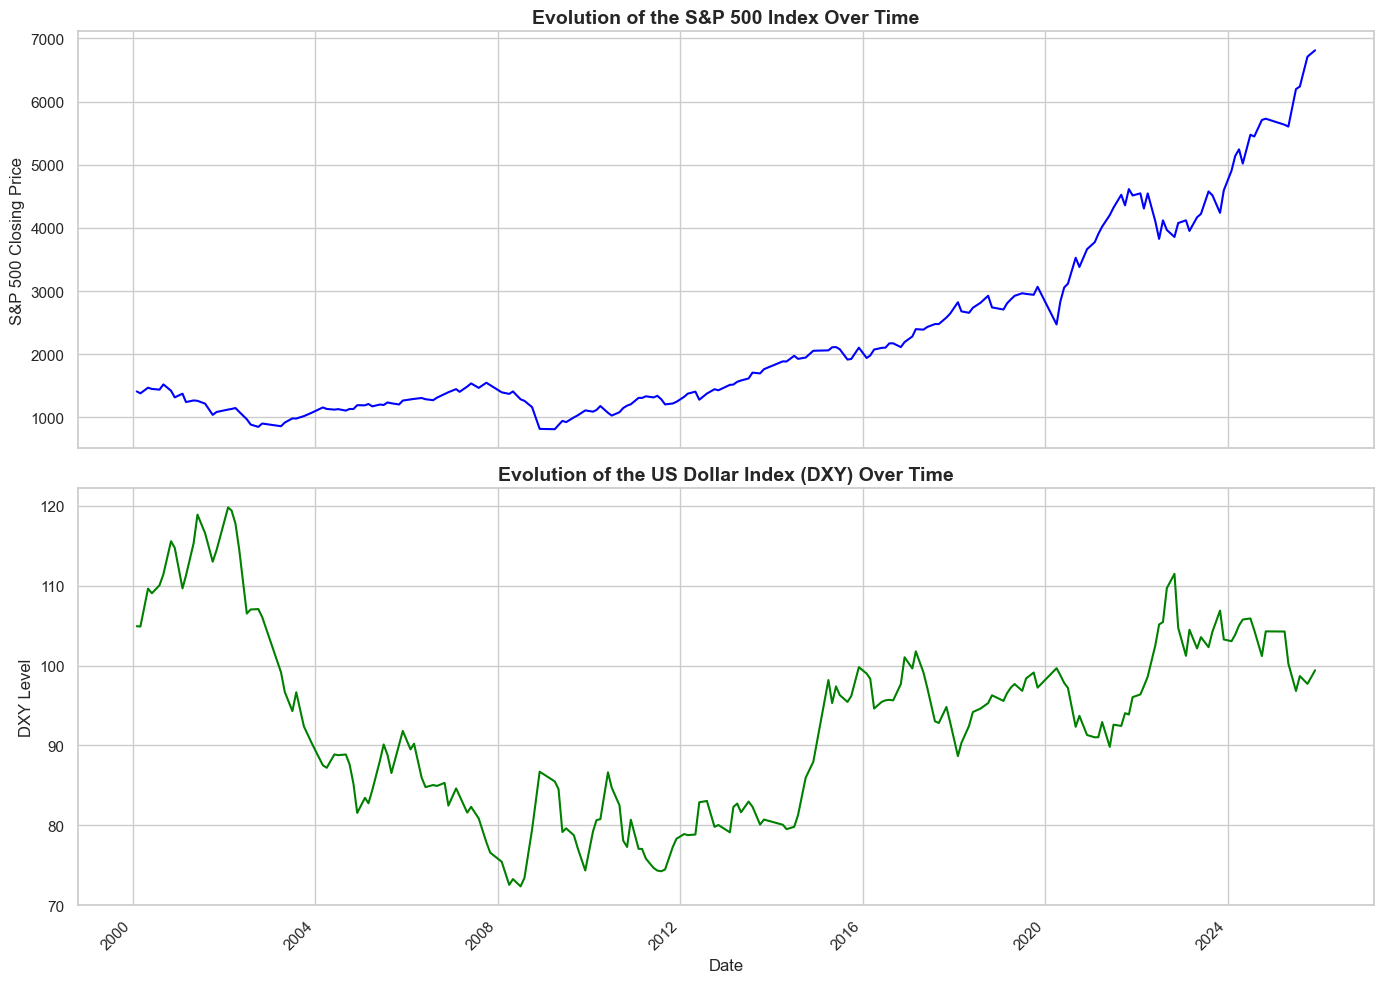

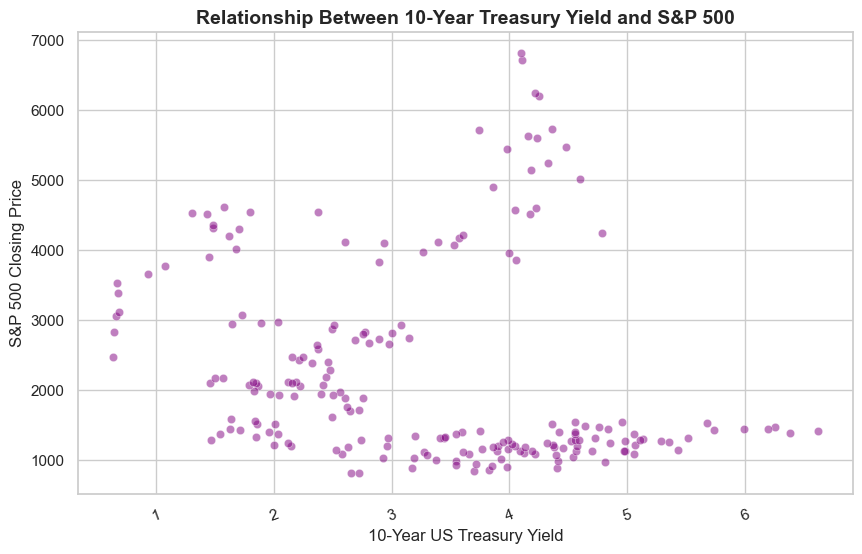

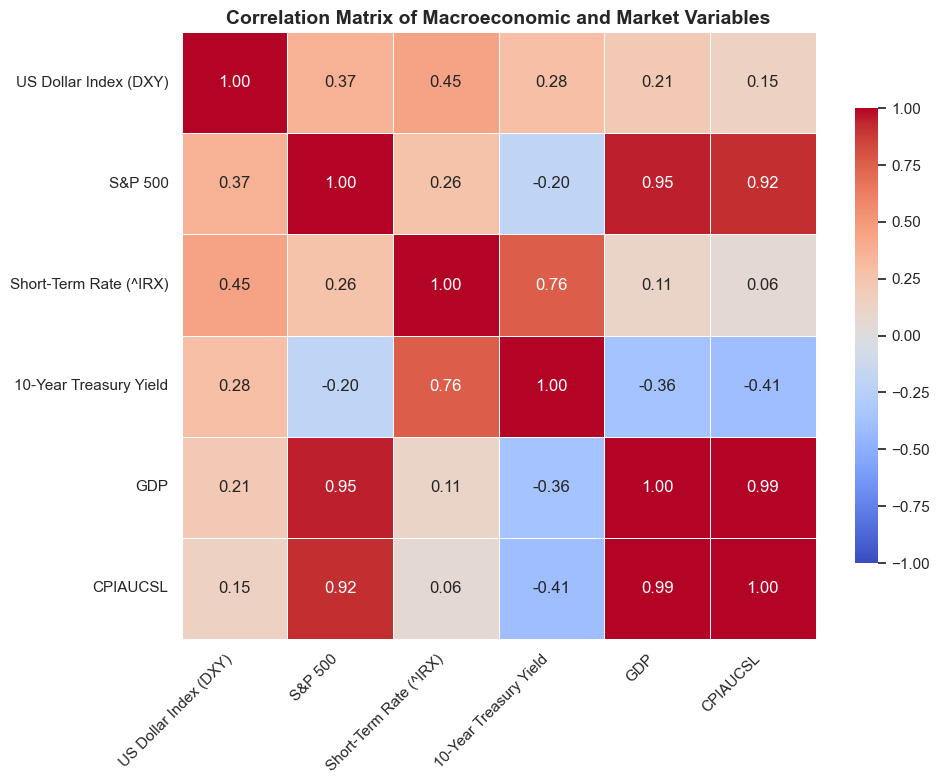

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Ensure seaborn style is applied for professional-looking plots
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Time-Series Line Charts: S&P 500 and US Dollar Index
# ---------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# Subplot 1: S&P 500 Evolution
axes[0].plot(df_merged.index, df_merged['S&P 500'], color='blue', linewidth=1.5)
axes[0].set_title('Evolution of the S&P 500 Index Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('S&P 500 Closing Price', fontsize=12)

# Subplot 2: US Dollar Index Evolution
axes[1].plot(df_merged.index, df_merged['US Dollar Index (DXY)'], color='green', linewidth=1.5)
axes[1].set_title('Evolution of the US Dollar Index (DXY) Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('DXY Level', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)

# Improve date formatting and rotate x-axis labels for readability
# Use a reasonable locator/formatter if many years are present
axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Scatterplot: 10-Year Treasury Yield vs S&P 500
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x='10-Year Treasury Yield', y='S&P 500', alpha=0.5, color='purple')
plt.title('Relationship Between 10-Year Treasury Yield and S&P 500', fontsize=14, fontweight='bold')
plt.xlabel('10-Year US Treasury Yield', fontsize=12)
plt.ylabel('S&P 500 Closing Price', fontsize=12)
# Rotate x ticks slightly if they are crowded (numeric ticks rarely need rotation)
plt.xticks(rotation=20)
plt.show()

# ---------------------------------------------------------
# 3. Correlation Matrix Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
# Calculate the Pearson correlation matrix
corr_matrix = df_merged.corr()

# Create the heatmap with seaborn
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1,
                 cbar_kws={'shrink': 0.75})
# Rotate x tick labels for better readability and align to the right
plt.xticks(rotation=45, ha='right')
# Keep y tick labels horizontal for readability
plt.yticks(rotation=0)
plt.title('Correlation Matrix of Macroeconomic and Market Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Feature Engineering: Data Transformation to Overcome Time Trends

During the initial Exploratory Data Analysis, a classic issue in financial time-series modeling often arises: plotting absolute equity index levels (such as the S&P 500) against cyclical indicators (like the 10-Year Treasury Yield) can obscure their true structural relationship. Equity markets tend to exhibit an exponential upward time trend over the long run, whereas bond yields oscillate within cyclical bounds defined by monetary policy.

To resolve this constraint and reveal the true underlying dynamics, we must apply mathematical data transformations. Specifically, we transition from analyzing absolute price blocks to analyzing percentage terms (returns). By calculating the monthly percentage change (`pct_change`), we effectively detrend the data. This transformation guarantees that our macroeconomic features are stationary, aligning closely with Data Science and econometric best practices.

Furthermore, we will introduce a new categorical feature—`Decade`—extracted from the Datetime index. Color-coding our scatterplot by economic eras (e.g., '2000s', '2010s', '2020s') will help us identify whether the correlation structure between equity returns and yield changes experiences a regime shift depending on the overarching macroeconomic environment.


In [ ]:
import numpy as np

# 1. Calculate Monthly Percentage Change (Returns)
# First we resample our daily series to monthly frequency to capture meaningful macroeconomic shifts
# We use the last trading day of the month ('ME' or 'M')
df_monthly = df_merged.resample('ME').last()

# Calculate the percentage change using .pct_change()
df_monthly['sp500_return'] = df_monthly['S&P 500'].pct_change()
df_monthly['tnx_change'] = df_monthly['10-Year Treasury Yield'].pct_change()

# 2. Extract the Decade from the Datetime index
# We calculate the decade by taking the year, dividing by 10, flooring it, and multiplying by 10
years = df_monthly.index.year
decades = (years // 10) * 10
# Map mapped values to a formatted string categorical column
df_monthly['Decade'] = decades.astype(str) + 's'

# 3. Drop the first row which contains NaN values produced by .pct_change()
df_monthly = df_monthly.dropna(subset=['sp500_return', 'tnx_change'])

print("Transformed Monthly Dataset Head:")
print(df_monthly[['S&P 500', 'sp500_return', '10-Year Treasury Yield', 'tnx_change', 'Decade']].head())

# ---------------------------------------------------------
# 4. Visualization: S&P 500 Returns vs 10-Year Yield Changes
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

# Create the scatterplot with Seaborn, adding hue for macroeconomic regimes (Decades)
sns.scatterplot(
    data=df_monthly,
    x='tnx_change',
    y='sp500_return',
    hue='Decade',
    palette='viridis',
    s=60,
    alpha=0.7,
    edgecolor='w'
)

# Add horizontal and vertical lines at 0 to define quadrants
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Formatting labels and title
plt.title('Monthly S&P 500 Returns vs 10-Year Treasury Yield Changes by Decade', fontsize=16, fontweight='bold')
plt.xlabel('10-Year Treasury Yield Monthly % Change (tnx_change)', fontsize=13)
plt.ylabel('S&P 500 Monthly % Return (sp500_return)', fontsize=13)

# Format axes as percentages for better readability
from matplotlib.ticker import PercentFormatter
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# Customize legend
plt.legend(title='Macroeconomic Era', title_fontsize='12', fontsize='11', loc='best')

plt.tight_layout()
plt.show()


# Advanced Exploratory Data Analysis: Economic Regimes and Regression Analysis

Our initial scatterplot of returns offered valuable insights but presented a seemingly structureless 'cloud' of points. In advanced Exploratory Data Analysis, when a bivariate relationship appears ambiguous, it often implies the presence of an unobserved mediating factor—a lurking variable that dictates different mathematical trends depending on the underlying economic state.

Furthermore, upon closer inspection of the macroeconomic data structure (specifically GDP), the true reporting frequency is quarterly (e.g., end of March, June, September, December). Thus, transforming the data on a quarterly basis yields a more accurate alignment of macroeconomic shifts and market reactions.

To expose the hidden trends within the data, we will:
1. **Calculate the Inflation Rate**: By computing the quarterly percentage change of the Consumer Price Index (CPI), we obtain the prevailing inflation rate.
2. **Define Economic Regimes**: We split the dataset into two distinct macroeconomic regimes—'High Inflation' and 'Low Inflation'—separated by the historical median of the inflation rate.
3. **Apply Regression Line Analysis**: We will plot the 10-Year Treasury Yield percentage change against the S&P 500 quarterly return, applying separate Ordinary Least Squares (OLS) regression lines (lines of best fit) for each inflation regime.

By categorizing the data into these regimes, the regression lines mathematically expose underlying trends that dictate how equity markets respond to yield changes under different inflationary pressures, a critical component of institutional quantitative research.


In [ ]:
# 1. Resample the daily merged dataset to a Quarterly frequency
# We use the last trading day of the quarter ('QE' or 'Q')
df_quarterly = df_merged.resample('QE').last()

# Calculate the quarterly percentage change (returns) for our core variables
df_quarterly['sp500_return'] = df_quarterly['S&P 500'].pct_change()
df_quarterly['tnx_change'] = df_quarterly['10-Year Treasury Yield'].pct_change()

# Calculate the inflation rate (Quarterly % change of CPI)
df_quarterly['Inflation_Rate'] = df_quarterly['CPIAUCSL'].pct_change()

# Drop the NaN values generated by the pct_change() operation before computing medians
df_quarterly = df_quarterly.dropna(subset=['sp500_return', 'tnx_change', 'Inflation_Rate'])

# 2. Define Economic Regimes based on the Inflation Rate median
median_inflation = df_quarterly['Inflation_Rate'].median()

# Create a new categorical column 'Inflation_Regime'
df_quarterly['Inflation_Regime'] = np.where(
    df_quarterly['Inflation_Rate'] > median_inflation,
    'High Inflation',
    'Low Inflation'
)

print(f"Historical Median Quarterly Inflation Rate: {median_inflation:.4%}")
print("\nQuarterly Dataset with Economic Regimes Head:")
print(df_quarterly[['sp500_return', 'tnx_change', 'Inflation_Rate', 'Inflation_Regime']].head())

# ---------------------------------------------------------
# 3. Visualization: Advanced Scatterplot with Regression Lines
# ---------------------------------------------------------
# We use seaborn.lmplot() to easily plot scatter points with OLS regression lines for different hues
g = sns.lmplot(
    data=df_quarterly,
    x='tnx_change',
    y='sp500_return',
    hue='Inflation_Regime',
    palette={'High Inflation': 'red', 'Low Inflation': 'blue'},
    height=7,
    aspect=1.5,
    scatter_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'w'},
    line_kws={'linewidth': 2}
)

# Formatting labels and title
plt.title('Quarterly S&P 500 Returns vs 10-Year Yield Changes by Inflation Regime', fontsize=16, fontweight='bold')
plt.xlabel('10-Year Treasury Yield Quarterly % Change (tnx_change)', fontsize=13)
plt.ylabel('S&P 500 Quarterly % Return (sp500_return)', fontsize=13)

# Format axes as percentages for better readability
from matplotlib.ticker import PercentFormatter
# Convert float to percentage (e.g., 0.05 -> 5%)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

plt.tight_layout()
plt.show()


# Feature Engineering and Dual-Axis Visualization: The Yield Curve Spread

Building on our advanced EDA, we will now apply domain-specific Feature Engineering to construct one of the most powerful leading macroeconomic indicators in finance: the **10-Year to 2-Year Treasury Yield Spread**.

By subtracting the short-term borrowing rate (represented by our 2-Year equivalent `^IRX`) from the long-term borrowing rate (the 10-Year Yield `^TNX`), we quantify the steepness of the yield curve.
- A **Normal** yield curve (Spread > 0) indicates a healthy, growing economy where investors demand higher yields for locking up money over longer periods.
- An **Inverted** yield curve (Spread $\le$ 0) suggests severe near-term economic distress and is historically viewed as a highly reliable leading indicator for impending recessions and equity market drawdowns.

Visualizing this phenomenon requires a **Dual-Axis Time Series Plot** (`ax.twinx()`), which aligns with Data Science best practices for "telling the right story" with disparate but interconnected data. We will plot the absolute level of the S&P 500 on the primary axis to track portfolio growth, and the Yield Spread on the secondary axis. To maximize visual impact, we will use programmatic highlighting (`fill_between()`) to shade periods where the yield curve deeply inverted. Finally, we will revisit our scatterplot to examine if these inverted states correlate with distinct market return profiles.


In [ ]:
import matplotlib.dates as mdates

# 1. Feature Engineering: Calculate the Yield Spread
# Note: df_merged columns were renamed earlier: '10-Year Treasury Yield' and 'Short-Term Rate (^IRX)'
df_merged['yield_spread'] = df_merged['10-Year Treasury Yield'] - df_merged['Short-Term Rate (^IRX)']

# Create a categorical column for the state of the yield curve
df_merged['yield_curve_state'] = np.where(df_merged['yield_spread'] > 0, 'Normal', 'Inverted')

print("Dataset with Yield Spread Features Head:")
print(df_merged[['10-Year Treasury Yield', 'Short-Term Rate (^IRX)', 'yield_spread', 'yield_curve_state']].head())

# ---------------------------------------------------------
# 2. Dual-Axis Time Series Plot: S&P 500 vs Yield Spread
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary Axis: S&P 500 (Absolute Price)
color1 = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('S&P 500 Closing Price', color=color1, fontsize=13, fontweight='bold')
ax1.plot(df_merged.index, df_merged['S&P 500'], color=color1, linewidth=1.5, label='S&P 500')
ax1.tick_params(axis='y', labelcolor=color1)

# Secondary Axis: Yield Spread
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('10Y - 2Y Yield Spread (%)', color=color2, fontsize=13, fontweight='bold')
ax2.plot(df_merged.index, df_merged['yield_spread'], color=color2, linewidth=1.5, alpha=0.8, label='Yield Spread')
ax2.tick_params(axis='y', labelcolor=color2)

# Add a horizontal line at 0 on the secondary axis to denote the inversion threshold
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.5)

# Highlighting: Shade the background red where the yield curve is inverted (Spread < 0)
ax2.fill_between(df_merged.index, 0, df_merged['yield_spread'],
                 where=(df_merged['yield_spread'] <= 0),
                 color='red', alpha=0.3, interpolate=True, label='Inverted Curve')

# Title and formatting
plt.title('S&P 500 Performance vs. Treasury Yield Curve Spread (10Y - 2Y)', fontsize=16, fontweight='bold')
fig.tight_layout()

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

plt.show()

# ---------------------------------------------------------
# 3. Updated Scatterplot: Returns colored by Yield Curve State
# ---------------------------------------------------------
# Re-calculate the daily regime on the monthly dataset for the scatterplot
df_monthly['yield_spread'] = df_monthly['10-Year Treasury Yield'] - df_monthly['Short-Term Rate (^IRX)']
df_monthly['yield_curve_state'] = np.where(df_monthly['yield_spread'] > 0, 'Normal', 'Inverted')

plt.figure(figsize=(10, 6))

# Scatterplot using the Yield Curve State as hue
sns.scatterplot(
    data=df_monthly,
    x='tnx_change',
    y='sp500_return',
    hue='yield_curve_state',
    palette={'Normal': 'green', 'Inverted': 'red'},
    s=60,
    alpha=0.7,
    edgecolor='w'
)

# Add horizontal and vertical lines at 0
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Formatting labels and title
plt.title('Monthly S&P 500 Returns vs 10-Year Yield Changes by Yield Curve State', fontsize=15, fontweight='bold')
plt.xlabel('10-Year Treasury Yield Monthly % Change (tnx_change)', fontsize=12)
plt.ylabel('S&P 500 Monthly % Return (sp500_return)', fontsize=12)

# Format axes as percentages for better readability
from matplotlib.ticker import PercentFormatter
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

plt.legend(title='Yield Curve State', fontsize='11', loc='best')
plt.tight_layout()
plt.show()


# Advanced Data Science: Lagged Relationships and Predictive Modeling

In macroeconomic and financial time-series analysis, the concept of **Lagged Relationships** is paramount. Leading indicators—such as the Yield Curve Spread—rarely exert their influence instantaneously. Instead, changes in the macroeconomic environment percolate through the real economy and financial markets over time.

By shifting (lagging) our data, we can test whether *past* states of the yield curve are better predictors of *future* market returns than concurrent (simultaneous) states. This technique transitions our analysis from a simple associative observation to a deeper exploratory and potentially predictive framework. Implementing lags allows us to vividly illustrate how the correlation between the yield spread and S&P 500 returns evolves over different time horizons (e.g., 1, 2, and 4 quarters later).


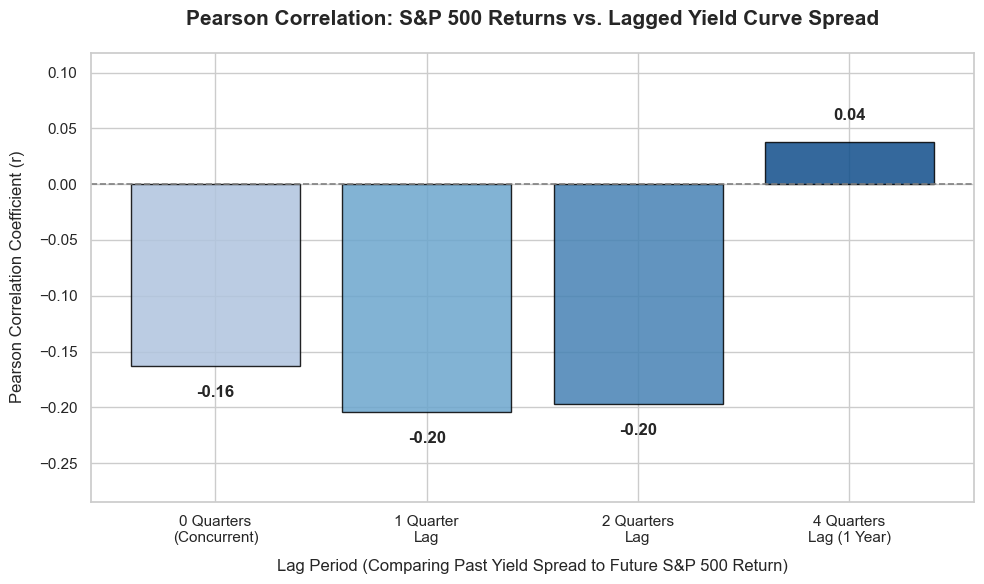

In [17]:
# 1. Feature Engineering: Create lagged versions of the Yield Spread
# Note: We apply this to our df_quarterly dataset because a shift of 1 exactly corresponds to 1 quarter,
# ensuring clean temporal alignment compared to shifting daily trading data.

# Ensure the spread is in the quarterly dataframe
df_quarterly['yield_spread'] = df_quarterly['10-Year Treasury Yield'] - df_quarterly['Short-Term Rate (^IRX)']

# We shift the spread FORWARD (positive shift) so that a past spread aligns with the current quarter's S&P 500 return.
# A shift of 1 means the spread from "1 quarter ago" sits on the same row as "today's return".
df_quarterly['spread_lag_1q'] = df_quarterly['yield_spread'].shift(1)
df_quarterly['spread_lag_2q'] = df_quarterly['yield_spread'].shift(2)
df_quarterly['spread_lag_4q'] = df_quarterly['yield_spread'].shift(4)

# Drop the NaN values introduced by shifting to calculate clean correlations
df_lagged_clean = df_quarterly.dropna(subset=['spread_lag_1q', 'spread_lag_2q', 'spread_lag_4q', 'sp500_return'])

# 2. Calculate Pearson correlation coefficients
corr_concurrent = df_lagged_clean['sp500_return'].corr(df_lagged_clean['yield_spread'])
corr_1q_lag     = df_lagged_clean['sp500_return'].corr(df_lagged_clean['spread_lag_1q'])
corr_2q_lag     = df_lagged_clean['sp500_return'].corr(df_lagged_clean['spread_lag_2q'])
corr_4q_lag     = df_lagged_clean['sp500_return'].corr(df_lagged_clean['spread_lag_4q'])

# Prepare lists for plotting
lags = ['0 Quarters\n(Concurrent)', '1 Quarter\nLag', '2 Quarters\nLag', '4 Quarters\nLag (1 Year)']
correlations = [corr_concurrent, corr_1q_lag, corr_2q_lag, corr_4q_lag]

# 3. Visualization: Professional Bar Chart of Correlations
plt.figure(figsize=(10, 6))

# Plot the bars with a unified professional color layout
bars = plt.bar(lags, correlations, color=['#b0c4de', '#6ca6cd', '#4682b4', '#104e8b'], edgecolor='black', alpha=0.85)

# Set y-axis limits dynamically with padding so labels don't overlap with the title or x-axis labels
y_min, y_max = min(correlations), max(correlations)
y_range = y_max - y_min
# Add 25% padding to top and bottom to ensure fonts are highly readable
plt.ylim(y_min - (y_range * 0.25) - 0.02, y_max + (y_range * 0.25) + 0.02)

# Add data labels on top of each bar showing the exact value rounded to 2 decimal places
for bar in bars:
    yval = bar.get_height()
    # Define a dynamically scaled offset based on the range of the data
    offset = (y_range * 0.05) + 0.005
    text_y = yval + offset if yval >= 0 else yval - offset
    va = 'bottom' if yval >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2, text_y, f'{yval:.2f}',
             ha='center', va=va, fontsize=12, fontweight='bold')

# Formatting labels, title and visual baseline
plt.title('Pearson Correlation: S&P 500 Returns vs. Lagged Yield Curve Spread', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Lag Period (Comparing Past Yield Spread to Future S&P 500 Return)', fontsize=12, labelpad=10)
plt.ylabel('Pearson Correlation Coefficient (r)', fontsize=12, labelpad=10)

# Add a horizontal line at 0 for easier visual grounding
plt.axhline(0, color='gray', linewidth=1.2, linestyle='--')

plt.tight_layout()
plt.show()
